<a href="https://colab.research.google.com/github/mobadara/finbert-sentiment-analyzer-api/blob/main/notebooks/eda_and_data_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FINANCIAL NEWS SENTIMENT ANALYSIS**
## 📈 **EDA & Data Engineering**


**Author:** [Muyiwa J. Obadara](https://portfolio-frontend-livid.vercel.app)

**Project:** FinBERT Sentiment API Backend

### **Objective**
The goal of this notebook is to perform Exploratory Data Analysis (EDA) and preprocess the **[Financial PhraseBank](https://huggingface.co/datasets/FinanceMTEB/financial_phrasebank)** dataset. Financial text is highly specialized; words that represent positive sentiment in a general context might represent risk in a financial context.

By analyzing the class distributions and cleaning the text, we will create a highly optimized dataset ready to fine-tune the `ProsusAI/finbert` model in the next phase of this pipeline.

### **Dataset Details**
* **Source:** `financial_phrasebank` (via Hugging Face Datasets)
* **Configuration:** `sentences_allagree` (Using only sentences where 100% of human annotators agreed on the sentiment)
* **Labels:** 0 (Negative), 1 (Neutral), 2 (Positive)

### **Setup**

In [ ]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['blue'])

In [ ]:
dataset = load_dataset('FinanceMTEB/financial_phrasebank')

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label_text', 'label'],
        num_rows: 1264
    })
    test: Dataset({
        features: ['text', 'label_text', 'label'],
        num_rows: 1000
    })
})

The dataset has two splits:
1. Train Dataset contains 1264 instances.
2. Test Dataset contains 1000 instances.

We need to convert the train dataset to a pandas datafrome exploration.

In [ ]:
df_train = dataset['train'].to_pandas()
df_train.head()

,text,label_text,label
0,The Samsung Mobile Applications Store was laun...,neutral,1
1,"F-Secure , a developer of security solutions a...",neutral,1
2,The company serves customers in various indust...,neutral,1
3,The company reported net sales of 302 mln euro...,neutral,1
4,Microsoft last week also issued the first patc...,neutral,1


We see that our dataset (in tabular form) contains three columns: **text**, **label_text** and **label**.

The **label_text** has three unique represents the sentiments of each text in human redable form, which can be **positive**, **negative** or **neutral**.

We need to see if the sentiments are uniformly distrivuted along the dataset.

In [ ]:
sentiment_counts = df_train['label_text'].value_counts()
print("Class Distribution:")
print(sentiment_counts)
print("-" * 30)

Class Distribution:
label_text
neutral     779
positive    320
negative    165
Name: count, dtype: int64
------------------------------


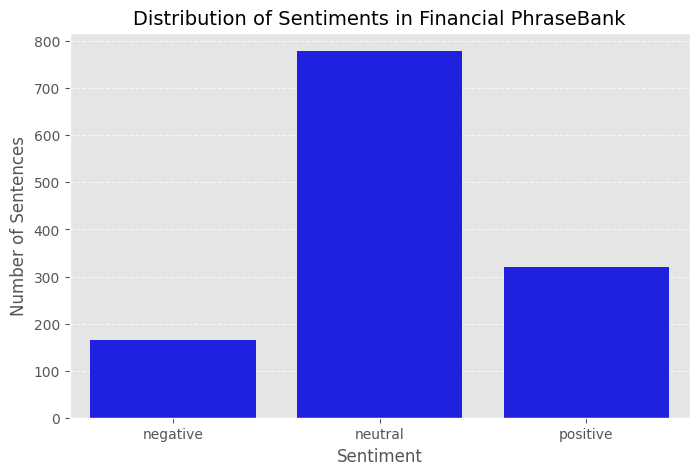

In [ ]:
# Visualize the imbalance
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train,
              x='label_text',
              order=['negative', 'neutral', 'positive'],)
plt.title('Distribution of Sentiments in Financial PhraseBank', fontsize=14)
plt.ylabel('Number of Sentences', fontsize=12)
plt.xlabel('Sentiment', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **Data Check and Cleaning**

In [ ]:
df_train.isna().sum()

,0
text,0
label_text,0
label,0


In [ ]:
df_train.duplicated().sum()

np.int64(1)

The train dataset does not cantain missing values in any column but a single entry was duplicated. We need to drop the duplicated column and save the newly cleaned dataset in out datasets directory.

In [ ]:
df_train.drop_duplicates(inplace=True)

In [ ]:
import os
os.makedirs('datasets', exist_ok=True)
df_train.to_csv('datasets/financial_phrasebank_train.csv', index=False)